# 1 — Imbault Lexicon Cleaning (+ visualization)

Reads Imbault supplemental CSV from `cfg["inputs"]["lexicon_file"]` and writes:
- `data/processed/imbault_l2_clean_va.csv`
- `data/processed/imbault_l1_clean_va.csv`
- `data/processed/imbault_gaps_va.csv`


In [9]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
from l2affect.utils.config import load_config, resolve
cfg = load_config(REPO_ROOT / ".." / "configs" / "config.yaml")
in_path = resolve(cfg["inputs"]["lexicon_file"])
out_dir = resolve(cfg["paths"]["processed_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(in_path)
df.head()

,Word,L2.Val.Mean,L2.Val.SD,L2.Val.N,L2.Aro.Mean,L2.Aro.SD,L2.Aro.N,L1.Val.Mean,L1.Val.SD,L1.Val.N,L1.Val.Mean.Young,L1.Val.SD.Young,L1.Val.N.Young,L1.Aro.Mean,L1.Aro.SD,L1.Aro.N,L1.Aro.Mean.Young,L1.Aro.SD.Young,L1.Aro.N.Young,Freq
0,abandon,2.43,1.68,60.0,3.58,1.95,57.0,2.84,1.54,19,2.75,1.28,8,3.73,2.43,22,3.78,2.28,9,413
1,abdomen,4.88,1.62,74.0,4.62,1.84,64.0,5.43,1.75,21,5.64,2.16,11,3.68,2.23,22,3.40,3.36,5,171
2,abduction,2.91,1.84,33.0,5.39,1.99,41.0,2.05,1.31,19,2.50,1.51,10,5.33,2.20,21,5.78,1.30,9,185
3,ability,7.33,1.59,15.0,5.29,1.96,17.0,7.00,1.59,20,7.00,1.66,9,4.85,2.74,20,4.78,2.86,9,980
4,able,NaN,NaN,NaN,5.35,2.28,20.0,6.64,1.79,22,6.29,1.86,14,3.38,2.25,21,2.78,1.64,9,8155


In [10]:
required = {"Word", "L2.Val.Mean", "L2.Aro.Mean", "L1.Val.Mean", "L1.Aro.Mean"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing expected columns: {missing}\nColumns found: {list(df.columns)}")

df["word"] = df["Word"].astype(str).str.strip().str.lower()
df = df.dropna(subset=["L2.Val.Mean","L2.Aro.Mean","L1.Val.Mean","L1.Aro.Mean"]).copy()

l2 = df[["word","L2.Val.Mean","L2.Aro.Mean","L2.Val.SD","L2.Aro.SD","L2.Val.N","L2.Aro.N","Freq"]].copy()
l2.columns = ["word","valence","arousal","valence_sd","arousal_sd","valence_n","arousal_n","freq"]

l1 = df[["word","L1.Val.Mean","L1.Aro.Mean","L1.Val.SD","L1.Aro.SD","L1.Val.N","L1.Aro.N","Freq"]].copy()
l1.columns = ["word","valence","arousal","valence_sd","arousal_sd","valence_n","arousal_n","freq"]

gaps = pd.DataFrame({
    "word": df["word"],
    "valence_l1": df["L1.Val.Mean"].astype(float),
    "arousal_l1": df["L1.Aro.Mean"].astype(float),
    "valence_l2": df["L2.Val.Mean"].astype(float),
    "arousal_l2": df["L2.Aro.Mean"].astype(float),
})
gaps["gap_valence"] = gaps["valence_l2"] - gaps["valence_l1"]
gaps["gap_arousal"] = gaps["arousal_l2"] - gaps["arousal_l1"]
gaps["gap_mag"] = np.sqrt(gaps["gap_valence"]**2 + gaps["gap_arousal"]**2)

l2_path = out_dir / "1-imbault_l2_clean_va.csv"
l1_path = out_dir / "1-imbault_l1_clean_va.csv"
gaps_path = out_dir / "1-imbault_gaps_va.csv"

l2.to_csv(l2_path, index=False)
l1.to_csv(l1_path, index=False)
gaps.to_csv(gaps_path, index=False)

print("Wrote:", l2_path)
print("Wrote:", l1_path)
print("Wrote:", gaps_path)
gaps.head()

Wrote: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\1-imbault_l2_clean_va.csv
Wrote: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\1-imbault_l1_clean_va.csv
Wrote: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\1-imbault_gaps_va.csv


,word,valence_l1,arousal_l1,valence_l2,arousal_l2,gap_valence,gap_arousal,gap_mag
0,abandon,2.84,3.73,2.43,3.58,-0.41,-0.15,0.436578
1,abdomen,5.43,3.68,4.88,4.62,-0.55,0.94,1.089082
2,abduction,2.05,5.33,2.91,5.39,0.86,0.06,0.862090
3,ability,7.00,4.85,7.33,5.29,0.33,0.44,0.550000
6,absence,3.86,4.30,3.42,3.72,-0.44,-0.58,0.728011


## quick visualizations saved to `reports/figures/` and `reports/tables/`

Saved to: C:\Users\hus44\Code\Directed-Reading-Project\reports\figures C:\Users\hus44\Code\Directed-Reading-Project\reports\tables


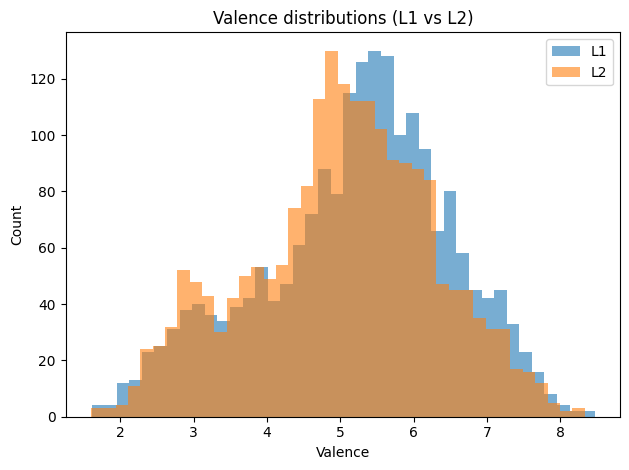

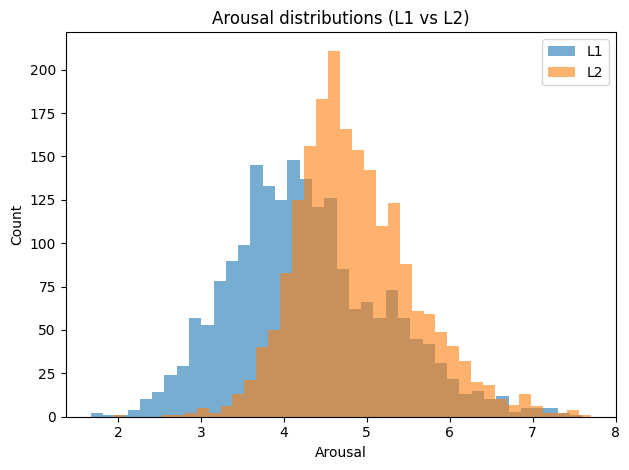

In [11]:
fig_dir = resolve(cfg["paths"]["reports_figures_dir"])
tbl_dir = resolve(cfg["paths"]["reports_tables_dir"])
fig_dir.mkdir(parents=True, exist_ok=True)
tbl_dir.mkdir(parents=True, exist_ok=True)

plt.figure()
plt.hist(gaps["valence_l1"], bins=40, alpha=0.6, label="L1")
plt.hist(gaps["valence_l2"], bins=40, alpha=0.6, label="L2")
plt.title("Valence distributions (L1 vs L2)")
plt.xlabel("Valence"); plt.ylabel("Count"); plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "valence_l1_vs_l2_hist.png", dpi=200)

plt.figure()
plt.hist(gaps["arousal_l1"], bins=40, alpha=0.6, label="L1")
plt.hist(gaps["arousal_l2"], bins=40, alpha=0.6, label="L2")
plt.title("Arousal distributions (L1 vs L2)")
plt.xlabel("Arousal"); plt.ylabel("Count"); plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "arousal_l1_vs_l2_hist.png", dpi=200)

gaps["abs_gap_valence"] = gaps["gap_valence"].abs()
gaps["abs_gap_arousal"] = gaps["gap_arousal"].abs()
gaps.sort_values("abs_gap_valence", ascending=False).head(50).to_csv(tbl_dir / "top_valence_gap_words.csv", index=False)
gaps.sort_values("abs_gap_arousal", ascending=False).head(50).to_csv(tbl_dir / "top_arousal_gap_words.csv", index=False)

print("Saved to:", fig_dir, tbl_dir)